In [1]:
from matplotlib import pyplot as plt
import re
import numpy as np
import pickle

In [2]:
with open('/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/circuit_depth_width/depths.p1.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
data.keys()

dict_keys(['test_N2_W2', 'test_N3_W4', 'test_N3_W5', 'test_N4_W5', 'test_N4_W6', 'test_N5_W6', 'test_N7_W2', 'test_N7_W3', 'test_N7_W4', 'test_N7_W5', 'test_N8_W2', 'test_N8_W3', 'test_N8_W4', 'test_N8_W5', 'test_N8_W6', 'test_N9_W6', 'test_N10_W6'])

In [4]:
data['test_N10_W6']['abstract']['operations']

OrderedDict([('rzz', 1960),
             ('ry', 360),
             ('rz', 240),
             ('measure', 120),
             ('barrier', 1)])

In [5]:
data['test_N3_W4']['hardware']['operations'], data['test_N3_W4']['hardware']['depth']

(OrderedDict([('rz', 1393),
              ('sx', 1360),
              ('cz', 670),
              ('delay', 382),
              ('measure', 24)]),
 60)

In [6]:
sum(v for k, v in data['test_N3_W4']['hardware']['operations'].items() if k in ['sx', 'rz', 'cz'])

3423

In [7]:
data['test_N4_W5']['hardware']['operations'], data['test_N4_W5']['hardware']['depth']

(OrderedDict([('sx', 3737),
              ('rz', 3397),
              ('cz', 1927),
              ('delay', 699),
              ('measure', 40)]),
 102)

In [8]:
sum(v for k, v in data['test_N4_W5']['hardware']['operations'].items() if k in ['sx', 'rz', 'cz'])

9061

In [9]:
widths = [data[f]['abstract']['width'] for f in data.keys()]
depths_abstract = np.array([data[f]['abstract']['depth'] for f in data.keys()])
counts_abstract = np.array([sum([v for k, v in data[f]['abstract']['operations'].items() if k == 'rzz']) for f in data.keys()])

depths_hardware = np.array([data[f]['hardware']['depth'] for f in data.keys()])
counts_hardware = np.array([sum([v for k, v in data[f]['hardware']['operations'].items() if k == 'cz']) for f in data.keys()])

In [15]:
data['test_N4_W6']['hardware']

{'depth': 126,
 'width': 48,
 'operations': OrderedDict([('sx', 5532),
              ('rz', 4876),
              ('cz', 2865),
              ('delay', 944),
              ('measure', 48)]),
 'circuit': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7f81f37839a0>}

In [49]:
from scipy.stats import binom
import numpy as np
two_q_median_error_rate = 1.24e-3
two_q_count = 2865
shots = 160000
tail = 0.01
desired_successes = 4000

p_success_shot = (1-two_q_median_error_rate)**two_q_count

expected_successes = binom.ppf(tail, shots, p_success_shot)
print(f'Number of expected success shots at {1-tail} confidence')
print(expected_successes)
p_success = binom.cdf(shots - desired_successes, shots, 1-p_success_shot)
print(f'Probability of at least {desired_successes} successes')
print(p_success)

new_shots = shots
rate = 0.1
while np.abs(expected_successes - desired_successes) > 10:
    new_shots = int((1 + rate * (1 if expected_successes < desired_successes else -1)) * new_shots)
    new_expected_successes = binom.ppf(tail, new_shots, p_success_shot)
    if (new_expected_successes - desired_successes) * (expected_successes - desired_successes) < 0:
        rate = rate * 0.1
    expected_successes = new_expected_successes
        
print(f'Number of total shots to obtain (roughly) {desired_successes} successes with {1-tail} confidence')
print(new_shots)


Number of expected success shots at 0.99 confidence
4420.0
Probability of at least 4000 successes
1.0
Number of total shots to obtain (roughly) 4000 successes with 0.99 confidence
145294


In [55]:
from scipy.stats import binom
two_q_layered_error_rate = 2.10e-3
two_q_count = 2865
shots = 400000
tail = 0.05
desired_successes = 4000

p_success_shot = (1-two_q_layered_error_rate)**two_q_count
expected_successes = binom.ppf(tail, shots, p_success_shot)
print(f'Number of expected success shots at {1-tail} confidence')
print(expected_successes)
p_success = binom.cdf(shots - desired_successes, shots, 1-p_success_shot)
print(f'Probability of at least {desired_successes} successes')
print(p_success)

new_shots = shots
rate = 0.25
while np.abs(expected_successes - desired_successes) > 10:
    new_shots = int((1 + rate * (1 if expected_successes < desired_successes else -1)) * new_shots)
    new_expected_successes = binom.ppf(tail, new_shots, p_success_shot)
    if (new_expected_successes - desired_successes) * (expected_successes - desired_successes) < 0:
        rate = rate * 0.1
        expected_successes = new_expected_successes
        
print(f'Number of total shots to obtain (roughly) {desired_successes} successes with {1-tail} confidence')
print(new_shots)

Number of expected success shots at 0.95 confidence
918.0
Probability of at least 4000 successes
0.0
Number of total shots to obtain (roughly) 4000 successes with 0.95 confidence
1697418


In [13]:
indices = np.argsort(widths)
print('filename qubits depths count')
for index in indices:
    print(np.array(list(data.keys()))[index], widths[index], depths_hardware[index], counts_hardware[index])

filename qubits depths count
test_N2_W2 8 21 67
test_N3_W4 24 60 670
test_N7_W2 28 78 987
test_N3_W5 30 78 1099
test_N8_W2 32 90 1320
test_N4_W5 40 102 1927
test_N7_W3 42 114 2233
test_N4_W6 48 126 2865
test_N8_W3 48 132 3007
test_N7_W4 56 150 3976
test_N5_W6 60 159 4516
test_N8_W4 64 174 5316
test_N7_W5 70 186 6272
test_N8_W5 80 216 8292
test_N8_W6 96 264 12290
test_N9_W6 108 294 15431
test_N10_W6 120 333 19336


In [74]:
grid = np.linspace(widths[0], widths[-1], 100)
p_depth = np.polynomial.Polynomial.fit(widths, depths_abstract, 1)
p_depth_hardware = np.polynomial.Polynomial.fit(widths, depths_hardware, 1)
p_count = np.polynomial.Polynomial.fit(widths, counts_abstract, 1)
p_count_hardware = np.polynomial.Polynomial.fit(widths, counts_hardware, 2)


In [75]:
min_hard_size = 17
min_hard_qubits = min_hard_size * (2*min_hard_size + 1)
p_depth(min_hard_qubits), p_count(min_hard_qubits)

(np.float64(920.3999024495989), np.float64(10031.986126165188))

Text(0.5, 1.0, '2-qubit gate depth and count for QUBO-QAOA')

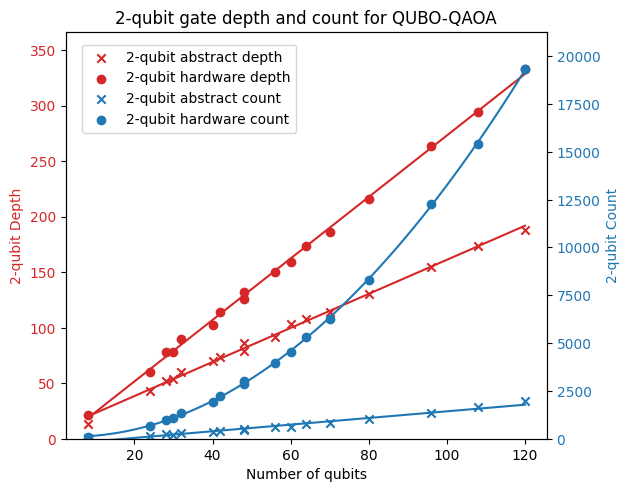

In [82]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.scatter(widths, depths_abstract, color=color, marker='x', label='2-qubit abstract depth')
ax1.scatter(widths, depths_hardware, color=color, label='2-qubit hardware depth')
# ax1.scatter([min_hard_qubits], [p_depth(min_hard_qubits)], color='k', label='Crossover point')
upper_y_lim = depths_hardware[-1] * 1.1
ax1.set_ylim(0, upper_y_lim)
upper_y_lim = ax1.get_ylim()[1]
# ax1.plot([min_hard_qubits, min_hard_qubits], [0, upper_y_lim], color='k')

ax1.plot(grid, p_depth(grid), color=color)
ax1.plot(grid, p_depth_hardware(grid), color=color)


ax1.set_xlabel('Number of qubits')
ax1.set_ylabel('2-qubit Depth', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.scatter(widths, counts_abstract, color=color, marker='x', label='2-qubit abstract count')
ax2.scatter(widths, counts_hardware, color=color, label='2-qubit hardware count')

ax2.plot(grid, p_count(grid), color=color)
ax2.plot(grid, p_count_hardware(grid), color=color)

ax2.set_ylabel('2-qubit Count', color=color)
ax2.set_ylim(0, counts_hardware[-1] * 1.1)
ax2.tick_params(axis='y', labelcolor=color)

fig.legend(loc=(0.13,0.73))
fig.tight_layout()
ax1.set_title('2-qubit gate depth and count for QUBO-QAOA')

In [ ]:
# median error rates
['%.2g' % x for x in (1 - 1.37E-3) ** counts_hardware ]

['0.91',
 '0.4',
 '0.22',
 '0.071',
 '0.02',
 '0.002',
 '0.26',
 '0.047',
 '0.0043',
 '0.00018',
 '0.16',
 '0.016',
 '0.00068',
 '1.2e-05',
 '4.8e-08',
 '6.5e-10',
 '3.1e-12']

In [ ]:
# best error rate
['%.2g' % x for x in (1 - 7.01E-4) ** counts_hardware ] 

['0.95',
 '0.63',
 '0.46',
 '0.26',
 '0.13',
 '0.042',
 '0.5',
 '0.21',
 '0.062',
 '0.012',
 '0.4',
 '0.12',
 '0.024',
 '0.003',
 '0.00018',
 '2e-05',
 '1.3e-06']

In [ ]:
# 0.5x best error rates
['%.2g' % x for x in (1 - 3.5E-4) ** counts_hardware ] 

['0.98',
 '0.79',
 '0.68',
 '0.51',
 '0.37',
 '0.21',
 '0.71',
 '0.46',
 '0.25',
 '0.11',
 '0.63',
 '0.35',
 '0.16',
 '0.055',
 '0.014',
 '0.0045',
 '0.0011']

In [1]:
(200000) / 2**80

1.6543612251060553e-19